<a href="https://colab.research.google.com/github/Hamtak0/DSP/blob/feature%2Fpower_spectrum/6610505250_Spectral_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spectral Analysis

## Generating the signal

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

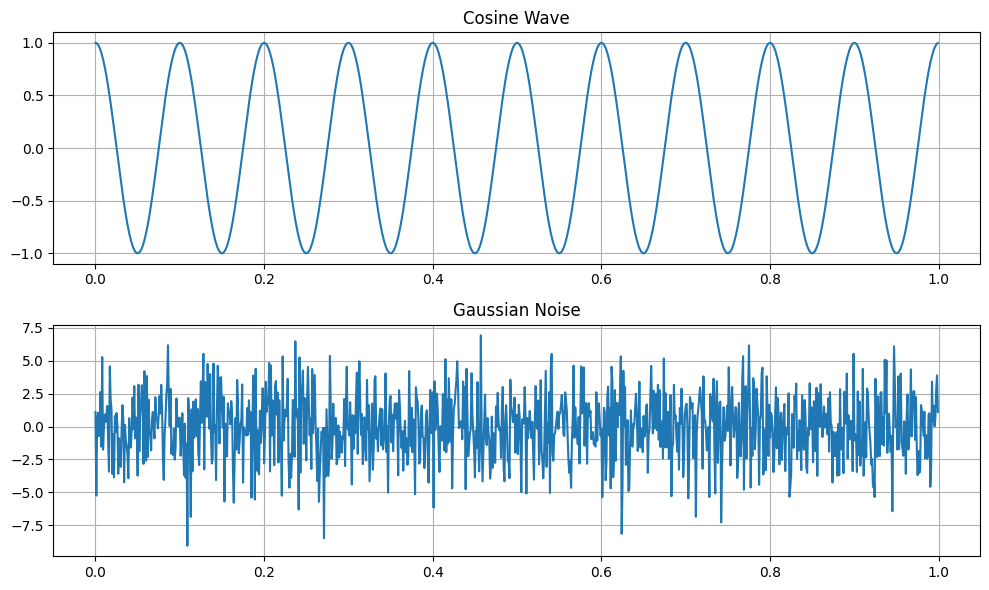

In [ ]:
'''
Start by generating cosine signal and white gaussian noise
'''
fs = 1000 # Sampling rate
N = 1 # Length of signal
t = np.linspace(0, N, fs, endpoint=False)

# Cosine wave signal
freq = 10

cosine_amplitude = 1
cosine_signal = np.cos(2 * np.pi * freq * t) * cosine_amplitude

# White gaussian noise
noise_amplitude = 2.5
noise = np.random.normal(0, 1, fs) * noise_amplitude

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, cosine_signal)
plt.title('Cosine Wave')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, noise)
plt.title('Gaussian Noise')
plt.grid()

plt.tight_layout()
plt.show()

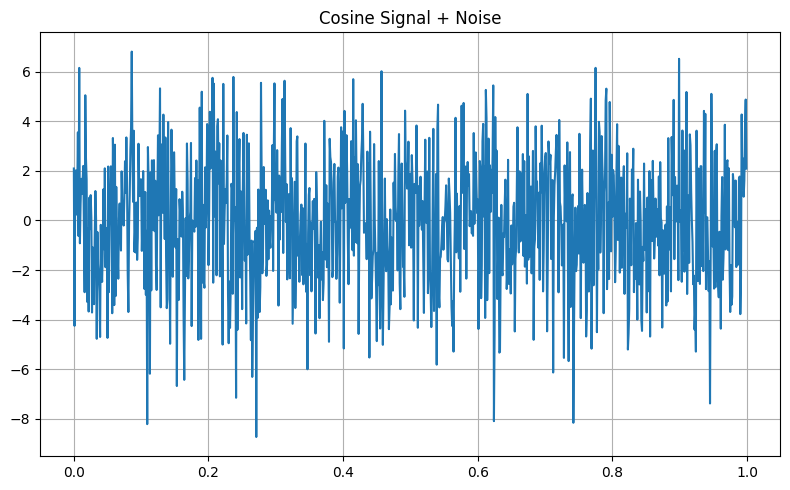

In [ ]:
'''
Combined 2 signals together
'''
combined_signal = cosine_signal + noise

plt.figure(figsize=(8, 5))

plt.plot(t, combined_signal)
plt.title('Cosine Signal + Noise')
plt.grid()

plt.tight_layout()
plt.show()

## Power Spectrum

### 1. Fourier Spectrum X(f)

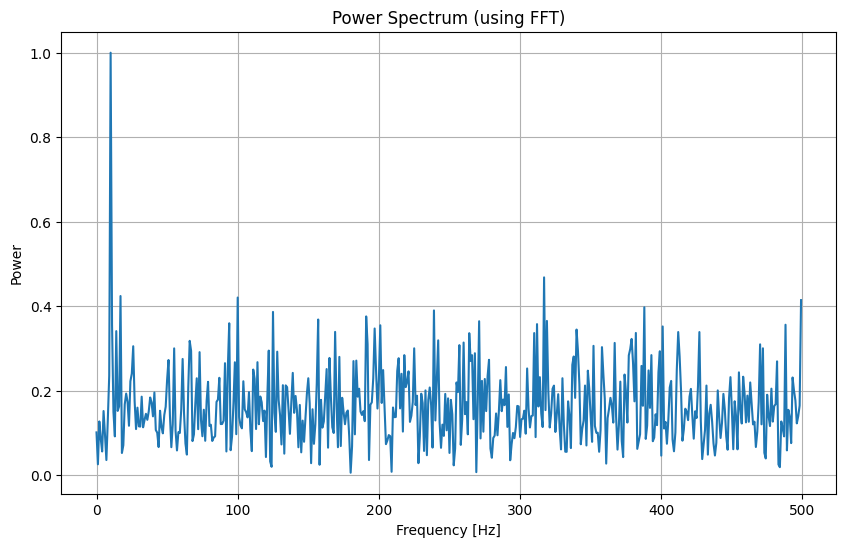

In [ ]:
'''
Normal fourier transform
- divided by max value to normalize 0-1
'''
fft_result = np.fft.fft(combined_signal)
power_spectrum = np.abs(fft_result)
frequencies = np.fft.fftfreq(len(combined_signal), 1/fs)
# Normalize
power_spectrum /= max(power_spectrum)

plt.figure(figsize=(10, 6))

plt.plot(frequencies[:len(frequencies)//2], power_spectrum[:len(power_spectrum)//2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.title('Power Spectrum (using FFT)')
plt.grid()
plt.show()

### 2. Periodogram

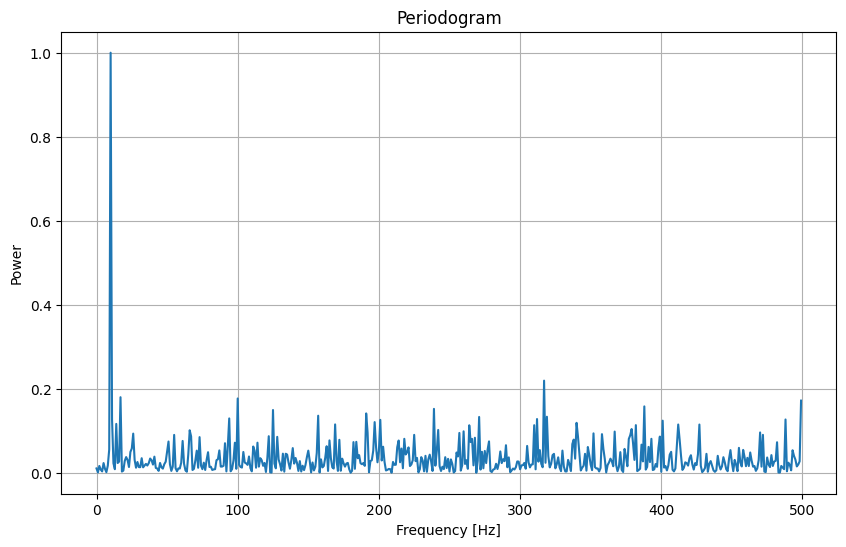

In [ ]:
'''
Using Periodogram approach
- DFT combined signal
- power the DFT by 2
- divided by size and max value to normalize 0-1
'''
fft_result = np.fft.fft(combined_signal)
periodogram = np.abs(fft_result)**2 / len(fft_result)
periodogram /= max(periodogram)
frequencies = np.fft.fftfreq(len(combined_signal), 1/fs)

plt.figure(figsize=(10, 6))

plt.plot(frequencies[:len(frequencies)//2], periodogram[:len(periodogram)//2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.title('Periodogram')
plt.grid()
plt.show()

### 3. Correlogram

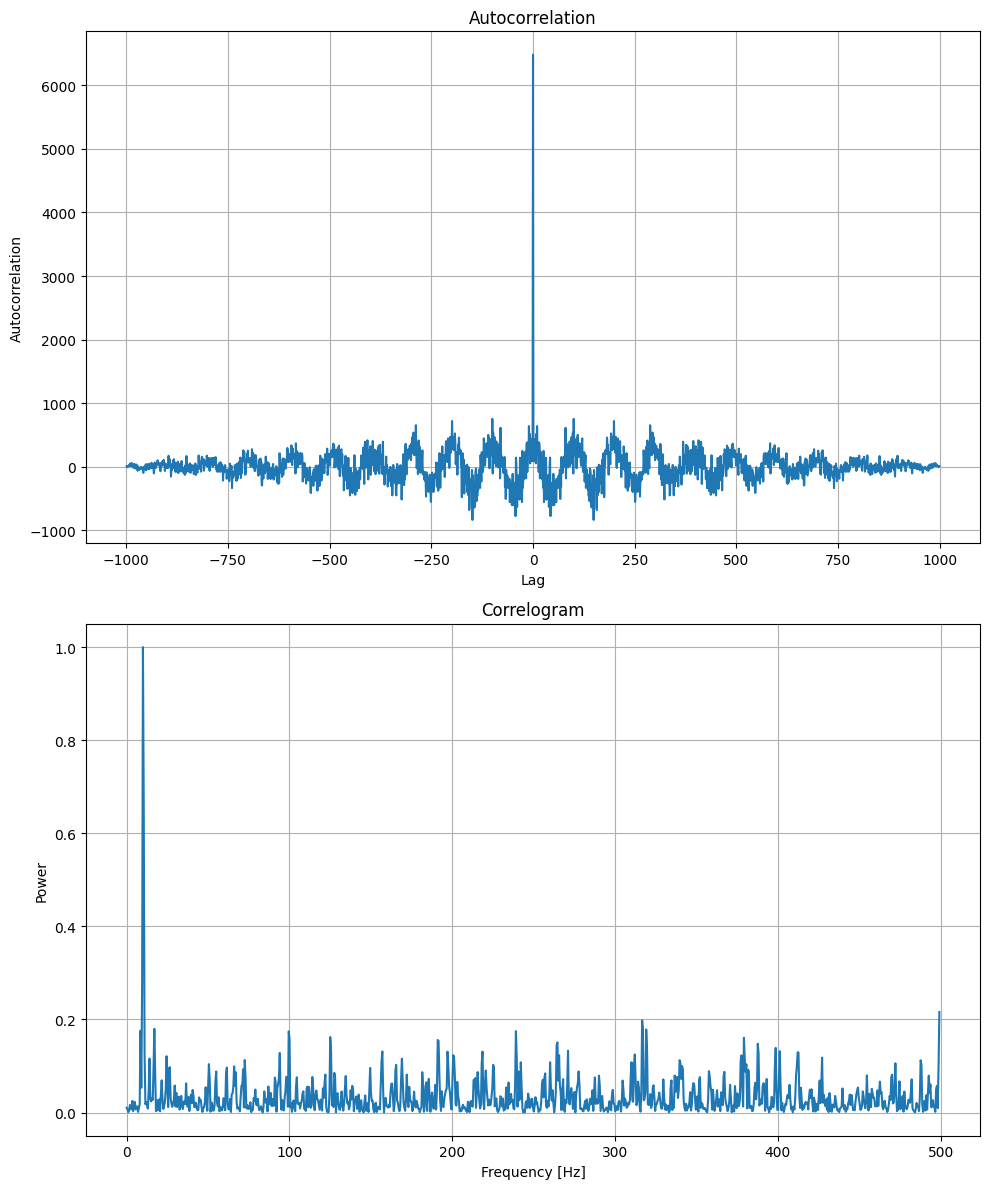

In [ ]:
'''
Using Correlogram approach
- auto correlate the combined signal
- take fourier transform
- divided by size and max value to normalize 0-1
'''
# Compute the autocorrelation
autocorr = np.correlate(combined_signal, combined_signal, mode='full')
fft_autocorr = np.fft.fft(autocorr)
power_spectrum_corr = np.abs(fft_autocorr) / len(combined_signal)
power_spectrum_corr /= max(power_spectrum_corr)

frequencies_corr = np.fft.fftfreq(len(autocorr), 1/fs)
# print(len(autocorr))
lags = np.arange(-(len(autocorr)//2), len(autocorr)//2+1, 1)
# print(len(lags))

plt.figure(figsize=(10, 12))

plt.subplot(2, 1, 1)
plt.plot(lags, autocorr)
plt.title('Autocorrelation')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(frequencies_corr[:len(frequencies_corr)//2], power_spectrum_corr[:len(power_spectrum_corr)//2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.title('Correlogram')
plt.grid()

plt.tight_layout()
plt.show()

### 4. Periodogram (Welch's method)

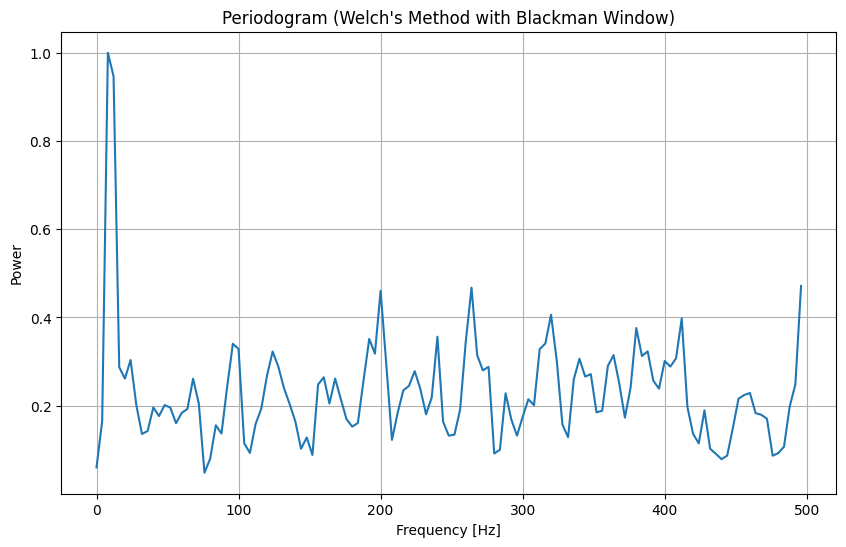

In [ ]:
'''
Generate by Gemini, Modified by Kongphop
Periodogram using blackman window
- overlapping 50% from segment_length
- average the frequency in the bin
'''
# Define segment length and overlap
segment_length = 250
# Overlap 50%
overlap = segment_length // 2
# Overlap 0% same as Bartlett's Method -> Lost some signal power due to window
# overlap = 0

# Number of data segment
K = len(combined_signal)//(segment_length - overlap) - 1

# Create segments with overlap
segments = []
for i in range(0, len(combined_signal) - segment_length + 1, segment_length - overlap):
    segment = combined_signal[i : i + segment_length]
    segments.append(segment)

# Create a Blackman window
blackman_window = np.blackman(segment_length)
U = np.sum(blackman_window**2) / segment_length

# Compute the periodogram for each segment and average
average_welch = np.zeros(segment_length // 2 + 1, dtype=np.complex256)
for segment in segments:
    # Apply the Blackman window
    windowed_segment = segment * blackman_window
    fft_result_segment = np.fft.fft(windowed_segment)
    periodogram_segment = np.abs(fft_result_segment)
    average_welch += periodogram_segment[:segment_length // 2 + 1]

# Normalize the power
periodogram_welch = np.abs(average_welch)**2 / (segment_length * U)
periodogram_welch /= K
periodogram_welch /= max(periodogram_welch)

# Get the corresponding frequencies
frequencies_welch = np.fft.fftfreq(segment_length, 1/fs)

# Plot the averaged periodogram
plt.figure(figsize=(10, 6))
plt.plot(frequencies_welch[:len(frequencies_welch)//2], periodogram_welch[:len(frequencies_welch)//2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.title("Periodogram (Welch's Method with Blackman Window)")
plt.grid()
plt.show()

### 5. Correlogram (Blackman and Tukey's method)

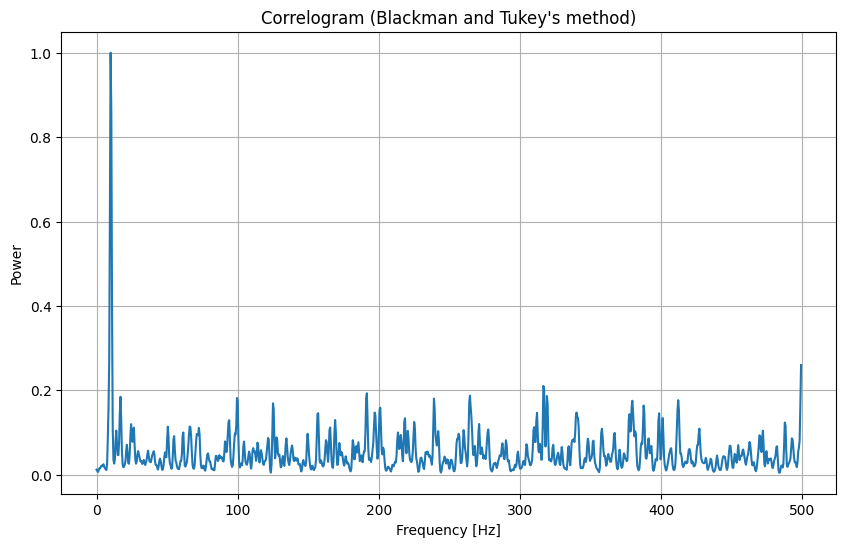

In [ ]:
'''
Correlogram using blackman window
- autocorrelate
- take blackman window to the signal
- trying to normalize using size, windowed power and max value
'''
# Compute the autocorrelation
autocorr = np.correlate(combined_signal, combined_signal, mode='full')
# Using blackman window to cover all the autocorrelate
blackman_window = np.blackman(len(autocorr))
windowed_autocorr = blackman_window * autocorr

# Trying to mimic the theory normalization in slide
U = np.sum(blackman_window**2) / (len(autocorr) // 2)

fft_autocorr = np.fft.fft(windowed_autocorr)
power_spectrum_corr = np.abs(fft_autocorr) / (len(combined_signal) * U)
power_spectrum_corr /= max(power_spectrum_corr)

frequencies_corr = np.fft.fftfreq(len(autocorr), 1/fs)
# print(len(autocorr))
lags = np.arange(-(len(autocorr)//2), len(autocorr)//2+1, 1)
# print(len(lags))

plt.figure(figsize=(10, 6))

plt.plot(frequencies_corr[:len(frequencies_corr)//2], power_spectrum_corr[:len(power_spectrum_corr)//2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.title("Correlogram (Blackman and Tukey's method)")
plt.grid()

plt.show()

## Using Library

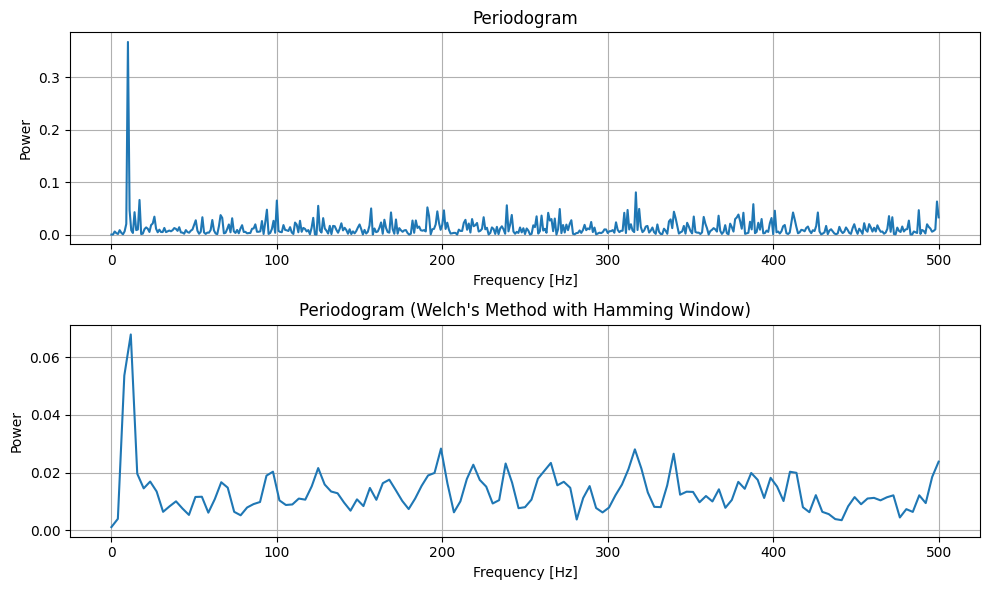

In [ ]:
import scipy.signal

periodogram_freq, periodogram_power = scipy.signal.periodogram(combined_signal, fs=fs)

welch_freq, welch_power = scipy.signal.welch(combined_signal, fs=fs, window='hamming')

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(periodogram_freq[:len(periodogram_freq)], periodogram_power[:len(periodogram_power)])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.title("Periodogram")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(welch_freq[:len(welch_freq)], welch_power[:len(welch_power)])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.title("Periodogram (Welch's Method with Hamming Window)")
plt.grid()

plt.tight_layout()
plt.show()

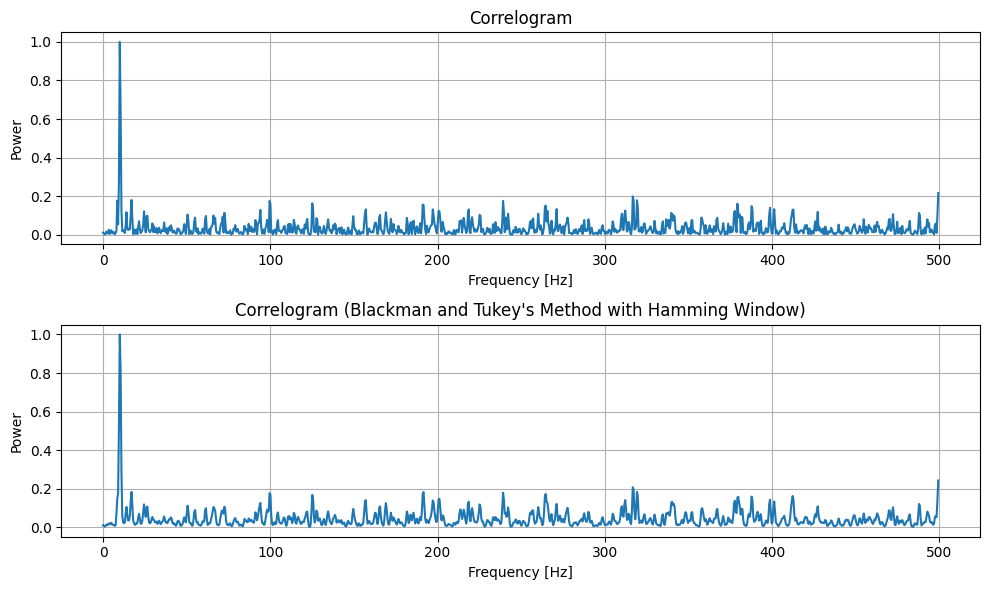

In [ ]:
import scipy.signal

autocorr = scipy.signal.correlate(combined_signal, combined_signal, mode='full')
correlogram_power = abs(scipy.fft.fft(autocorr)) / len(autocorr)
# Normalize using sampling rate
correlogram_power /= max(correlogram_power)
correlogram_freq = scipy.fft.fftfreq(len(autocorr), d=1/fs)

hamming_window = np.hamming(len(autocorr))
windowed_autocorr = autocorr * hamming_window
blackmantukey_power = abs(scipy.fft.fft(windowed_autocorr)) / len(windowed_autocorr)
# Normalize using sampling rate
blackmantukey_power /= max(blackmantukey_power)
blackmantukey_freq = scipy.fft.fftfreq(len(windowed_autocorr), d=1/fs)

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(correlogram_freq[:len(correlogram_freq)//2], correlogram_power[:len(correlogram_power)//2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.title("Correlogram")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(blackmantukey_freq[:len(blackmantukey_freq)//2], blackmantukey_power[:len(blackmantukey_power)//2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.title("Correlogram (Blackman and Tukey's Method with Hamming Window)")
plt.grid()

plt.tight_layout()
plt.show()